# Large-Scale Amazon Customer Review Analytics using PySpark
## Checkpoint 1 - Data Understanding, Preprocessing and Objectives 1 to 4

**Ahsanullah University of Science and Technology**
Department of Computer Science and Engineering

**Course:** CSE 4262 - Data Analytics Lab  
**Lab Group:** Gr-03 | **Group:** Gr-06  
**Prepared for:** Mr. Md Hasan Al Kayem, Lecturer Grade-I and Dr. Afsana Ahmed Munia, Assistant Professor

| Student ID | Name |
|---|---|
| 20220104006 | A.S.M. Tahsin Tajware |
| 20220104014 | Abdullah Al Tamim |
| 20220104032 | Eusha Ahmed Mahi |


## 1. Environment, Dataset and Output Folders

This section starts the Spark session, locates `Amazon_Reviews.csv`, and creates the folders
that every table and figure in this notebook is written to.


In [1]:
try:
    import pyspark
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyspark"], check=True)
    import pyspark

import os, glob, time, gc, warnings
warnings.filterwarnings("ignore")

def find_dataset():
    hits = []
    for base in ["/kaggle/input", "/mnt/user-data/uploads", "./data", "."]:
        if os.path.isdir(base):
            hits += glob.glob(os.path.join(base, "**", "*.csv"), recursive=True)
    hits = [h for h in hits if "results" not in h and "figures" not in h]
    if not hits:
        raise FileNotFoundError("Amazon_Reviews.csv not found. Set DATA_PATH manually.")
    preferred = [h for h in hits if any(k in os.path.basename(h).lower()
                                        for k in ("amazon", "review"))]
    return sorted(preferred or hits, key=os.path.getsize, reverse=True)[0]

DATA_PATH = find_dataset()
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.path.abspath("./output")
FIG_DIR = os.path.join(OUT_DIR, "figures")
TBL_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

print("PySpark version :", pyspark.__version__)
print("Dataset         :", DATA_PATH)
print("File size       : %.1f MB" % (os.path.getsize(DATA_PATH) / 1e6))
print("Figures folder  :", FIG_DIR)
print("Results folder  :", TBL_DIR)

PySpark version : 4.0.2
Dataset         : /kaggle/input/datasets/tahsintajware/amazon/Amazon_Reviews.csv
File size       : 174.5 MB
Figures folder  : /kaggle/working/figures
Results folder  : /kaggle/working/results


In [2]:
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType, DoubleType,
                               LongType, IntegerType, BooleanType)

spark = (SparkSession.builder
         .appName("Large-Scale Amazon Customer Review Analytics - Gr-03")
         .master("local[*]")
         .config("spark.driver.memory", "8g")
         .config("spark.driver.maxResultSize", "2g")
         .config("spark.sql.shuffle.partitions", "16")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print("Spark version :", spark.version)
print("Master        :", spark.sparkContext.master)
print("Cores         :", spark.sparkContext.defaultParallelism)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/05 14:30:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version : 4.0.2
Master        : local[*]
Cores         : 4


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

CATS = ["Cell Phones", "Video Games", "Beauty"]
CAT_COLORS = {"Cell Phones": "#2563eb", "Video Games": "#16a34a", "Beauty": "#db2777"}
STAR_COLORS = ["#ef4444", "#f97316", "#eab308", "#84cc16", "#16a34a"]
ACCENT = "#2563eb"
ccol = lambda c: CAT_COLORS.get(c, "#64748b")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RESULTS = {}
FIGURES = {}

def savefig(fig, name, caption=""):
    path = os.path.join(FIG_DIR, name + ".png")
    fig.savefig(path)
    FIGURES[name] = caption or name
    print("figure saved ->", path)

def save_table(obj, name, show=False, n=10):
    pdf = obj.toPandas() if hasattr(obj, "toPandas") else pd.DataFrame(obj).copy()
    pdf.to_csv(os.path.join(TBL_DIR, name + ".csv"), index=False)
    try:
        pdf.to_parquet(os.path.join(TBL_DIR, name + ".parquet"), index=False)
    except Exception as e:
        print("   parquet skipped:", type(e).__name__)
    RESULTS[name] = pdf
    print(f"table saved  -> {name}  ({len(pdf)} rows)")
    if show:
        print(pdf.head(n).to_string(index=False))
    return pdf

print("Plot style, figure saver and table saver ready.")

Plot style, figure saver and table saver ready.


## 2. Dataset Loading and Profiling

The schema is declared explicitly instead of relying on inference, so column types are fixed
and a malformed value cannot silently change a column's type. Profiling runs on the raw
DataFrame before any cleaning, because a null grouping key can quietly disappear from a
`groupBy` and go unnoticed otherwise.


In [4]:
schema = StructType([
    StructField("asin",              StringType(),  True),
    StructField("helpful_vote",      IntegerType(), True),
    StructField("images",            StringType(),  True),
    StructField("parent_asin",       StringType(),  True),
    StructField("rating",            DoubleType(),  True),
    StructField("text",              StringType(),  True),
    StructField("timestamp",         LongType(),    True),
    StructField("title",             StringType(),  True),
    StructField("user_id",           StringType(),  True),
    StructField("verified_purchase", BooleanType(), True),
    StructField("Category",          StringType(),  True),
])

CSV_OPTS = dict(header=True, quote='"', escape='"', multiLine=True, mode="PERMISSIVE")

def read_raw(tag=None):
    r = spark.read.options(**CSV_OPTS).schema(schema).csv(DATA_PATH)
    return r.withColumn("_src", F.lit(tag)) if tag else r

raw = read_raw().cache()
n_raw = raw.count()
print(f"Rows loaded: {n_raw:,}")
raw.printSchema()

Rows loaded: 521,607
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: integer (nullable = true)
 |-- images: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- Category: string (nullable = true)



In [5]:
raw.select("Category", "rating", "verified_purchase", "helpful_vote",
           F.substring("title", 1, 30).alias("title"),
           F.substring("text", 1, 55).alias("text_preview")).show(5, truncate=False)

+--------+------+-----------------+------------+------------------------------+-------------------------------------------------------+
|Category|rating|verified_purchase|helpful_vote|title                         |text_preview                                           |
+--------+------+-----------------+------------+------------------------------+-------------------------------------------------------+
|Beauty  |5.0   |false            |0           |Quality hair iron, works perfe|This is a great hair straightener. Heats up quickly and|
|Beauty  |5.0   |true             |0           |Doesn't Irritate My Skin      |A few months ago I got a vanity mirror that magnifies 5|
|Beauty  |4.0   |false            |0           |Slight Fading of Burns So Far |I burned my back of my hand in a couple of spots this p|
|Beauty  |2.0   |false            |0           |Lotion-zip, too heavily scente|I received this gift set for Christmas. My husband orde|
|Beauty  |5.0   |false            |2           |

### 2.1 Table 1 - Dataset summary

`None`, `NaN`, `NULL` and empty strings are all treated as missing, matching how pandas reads
the same file, so the missing-value counts here are comparable to the proposal.


In [6]:
NA_TOKENS = ['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan',
             '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', 'None', 'n/a', 'nan', 'null']

def missing(colname):
    c = F.col(colname)
    return c.isNull() | c.isin(NA_TOKENS)

summary = raw.select(
    F.count("*").alias("total_records"),
    F.countDistinct("user_id").alias("unique_reviewers"),
    F.countDistinct("asin").alias("unique_products"),
    F.countDistinct("parent_asin").alias("unique_parent_products"),
    F.sum(F.col("verified_purchase").cast("int")).alias("verified"),
    F.sum((~F.col("verified_purchase")).cast("int")).alias("non_verified"),
    F.sum(missing("text").cast("int")).alias("missing_text"),
    F.sum(missing("title").cast("int")).alias("missing_title"),
    F.min((F.col("timestamp") / 1000).cast("timestamp")).alias("earliest"),
    F.max((F.col("timestamp") / 1000).cast("timestamp")).alias("latest"),
).first()

tot = summary["total_records"]
tbl1 = pd.DataFrame([
    ("Total records",           f"{tot:,} customer reviews"),
    ("Date range",              f"{summary['earliest'].date()} to {summary['latest'].date()}"),
    ("Categories",              ", ".join(CATS)),
    ("Verified / non-verified", f"{summary['verified']:,} ({summary['verified']/tot:.1%}) / "
                                f"{summary['non_verified']:,} ({summary['non_verified']/tot:.1%})"),
    ("Unique reviewers",        f"{summary['unique_reviewers']:,}"),
    ("Unique products (asin)",  f"{summary['unique_products']:,}"),
    ("Unique parent products",  f"{summary['unique_parent_products']:,}"),
    ("Missing review text",     f"{summary['missing_text']} ({summary['missing_text']/tot:.3%})"),
    ("Missing review title",    f"{summary['missing_title']} ({summary['missing_title']/tot:.3%})"),
], columns=["Attribute", "Value"])

print("Table 1 - Dataset summary")
save_table(tbl1, "tbl01_dataset_summary")
tbl1

Table 1 - Dataset summary
table saved  -> tbl01_dataset_summary  (9 rows)


,Attribute,Value
0,Total records,"521,607 customer reviews"
1,Date range,1999-09-17 to 2023-09-11
2,Categories,"Cell Phones, Video Games, Beauty"
3,Verified / non-verified,"485,784 (93.1%) / 35,823 (6.9%)"
4,Unique reviewers,"504,856"
5,Unique products (asin),"227,791"
6,Unique parent products,"193,816"
7,Missing review text,186 (0.036%)
8,Missing review title,156 (0.030%)


### 2.2 Tables 2 and 3 - Category and rating distribution

In [7]:
cat_dist = (raw.groupBy("Category").count()
            .withColumn("share_pct", F.round(100 * F.col("count") / tot, 1))
            .orderBy(F.desc("count")))
rating_dist = (raw.groupBy("rating").count()
               .withColumn("share_pct", F.round(100 * F.col("count") / tot, 1))
               .orderBy("rating"))

print("Table 2 - Category distribution")
cat_dist.show(truncate=False)
print("Table 3 - Rating distribution (marketplace-wide)")
rating_dist.show(truncate=False)

save_table(cat_dist, "tbl02_category_distribution")
save_table(rating_dist, "tbl03_rating_distribution");

Table 2 - Category distribution
+-----------+------+---------+
|Category   |count |share_pct|
+-----------+------+---------+
|Cell Phones|415467|79.7     |
|Video Games|91966 |17.6     |
|Beauty     |14174 |2.7      |
+-----------+------+---------+

Table 3 - Rating distribution (marketplace-wide)
+------+------+---------+
|rating|count |share_pct|
+------+------+---------+
|1.0   |69518 |13.3     |
|2.0   |30771 |5.9      |
|3.0   |38826 |7.4      |
|4.0   |62515 |12.0     |
|5.0   |319977|61.3     |
+------+------+---------+

table saved  -> tbl02_category_distribution  (3 rows)
table saved  -> tbl03_rating_distribution  (5 rows)


### 2.3 Tables 4 and 5 - Rating by category, and review length by rating

In [8]:
cat_stats = (raw.groupBy("Category")
             .agg(F.round(F.avg("rating"), 2).alias("avg_rating"),
                  F.round(100 * F.avg(F.col("verified_purchase").cast("int")), 1).alias("verified_share_pct"),
                  F.count("*").alias("reviews"))
             .orderBy(F.desc("avg_rating")))

len_by_rating = (raw.withColumn("len", F.length(F.coalesce(F.col("text"), F.lit(""))))
                 .groupBy("rating")
                 .agg(F.round(F.avg("len")).cast("int").alias("avg_len_chars"))
                 .orderBy("rating"))

print("Table 4 - Average rating and verified share by category")
cat_stats.show(truncate=False)
print("Table 5 - Average review-text length by star rating")
len_by_rating.show(truncate=False)

save_table(cat_stats, "tbl04_category_stats")
save_table(len_by_rating, "tbl05_length_by_rating");

Table 4 - Average rating and verified share by category
+-----------+----------+------------------+-------+
|Category   |avg_rating|verified_share_pct|reviews|
+-----------+----------+------------------+-------+
|Video Games|4.05      |86.0              |91966  |
|Cell Phones|4.02      |94.8              |415467 |
|Beauty     |3.96      |90.5              |14174  |
+-----------+----------+------------------+-------+

Table 5 - Average review-text length by star rating


+------+-------------+
|rating|avg_len_chars|
+------+-------------+
|1.0   |202          |
|2.0   |275          |
|3.0   |280          |
|4.0   |283          |
|5.0   |164          |
+------+-------------+

table saved  -> tbl04_category_stats  (3 rows)


table saved  -> tbl05_length_by_rating  (5 rows)


### 2.4 Engagement profile of helpful votes

Helpful votes are the most skewed field in the dataset. The median and 75th percentile both sit
at zero while a handful of reviews collect thousands of votes, so the mean on its own is
misleading and any helpfulness feature has to be built with that skew in mind.


In [9]:
q = raw.approxQuantile("helpful_vote", [0.5, 0.75, 0.9, 0.99], 0.001)
hv_stats = raw.select(
    F.round(F.avg("helpful_vote"), 3).alias("mean"),
    F.max("helpful_vote").alias("max"),
    F.round(100 * F.avg((F.col("helpful_vote") >= 1).cast("int")), 1).alias("pct_with_any_vote"),
).first()

tbl_hv = pd.DataFrame([
    ("Mean helpful votes",       hv_stats["mean"]),
    ("Median (p50)",             q[0]),
    ("75th percentile",          q[1]),
    ("90th percentile",          q[2]),
    ("99th percentile",          q[3]),
    ("Maximum",                  hv_stats["max"]),
    ("Reviews with >=1 vote (%)", hv_stats["pct_with_any_vote"]),
], columns=["Statistic", "Value"])

print("Helpful-vote engagement profile")
save_table(tbl_hv, "tbl06_helpful_vote_profile")
tbl_hv

Helpful-vote engagement profile
table saved  -> tbl06_helpful_vote_profile  (7 rows)


,Statistic,Value
0,Mean helpful votes,0.704
1,Median (p50),0.000
2,75th percentile,0.000
3,90th percentile,1.000
4,99th percentile,11.000
5,Maximum,"7,663.000"
6,Reviews with >=1 vote (%),17.100


### 2.5 Figure 1 - Profiling overview

figure saved -> /kaggle/working/figures/fig01_dataset_profile.png


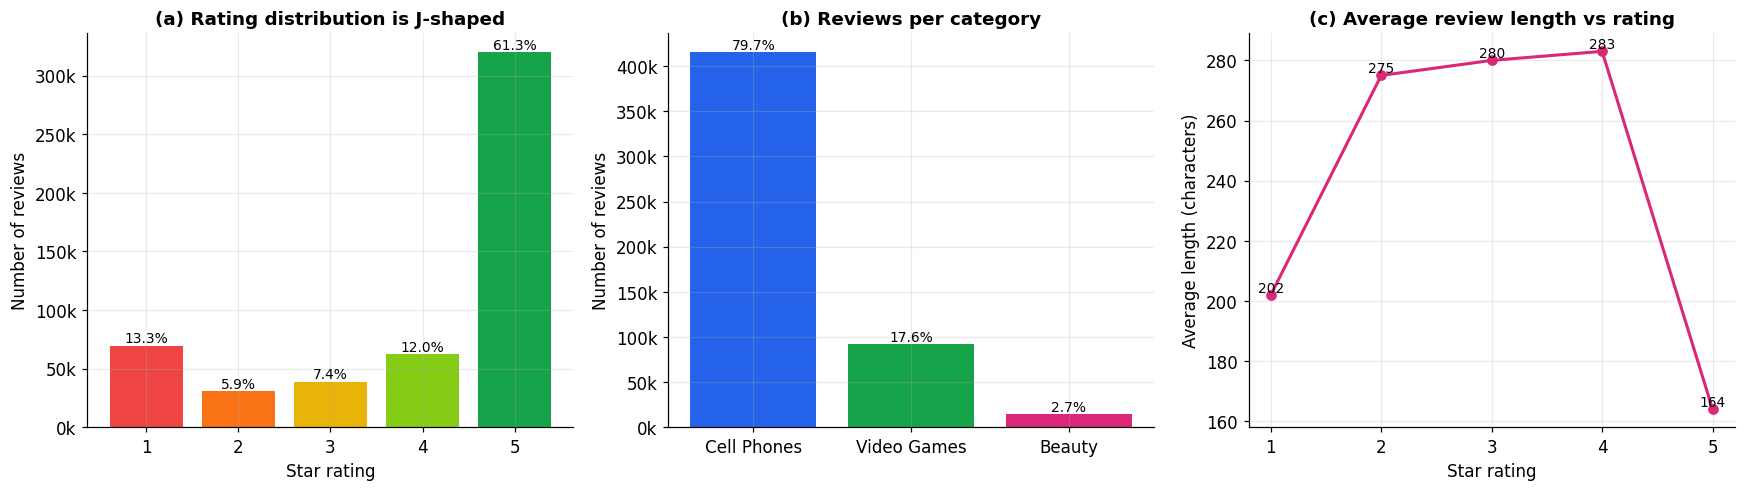

In [10]:
rd, cd, lbr = rating_dist.toPandas(), cat_dist.toPandas(), len_by_rating.toPandas()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

bars = ax[0].bar(rd["rating"].astype(int).astype(str), rd["count"], color=STAR_COLORS)
ax[0].set_title("(a) Rating distribution is J-shaped")
ax[0].set_xlabel("Star rating"); ax[0].set_ylabel("Number of reviews")
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
for b, s in zip(bars, rd["share_pct"]):
    ax[0].text(b.get_x() + b.get_width()/2, b.get_height(), f"{s}%", ha="center", va="bottom", fontsize=9)

ax[1].bar(cd["Category"], cd["count"], color=[ccol(c) for c in cd["Category"]])
ax[1].set_title("(b) Reviews per category"); ax[1].set_ylabel("Number of reviews")
ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
for i, (c, s) in enumerate(zip(cd["count"], cd["share_pct"])):
    ax[1].text(i, c, f"{s}%", ha="center", va="bottom", fontsize=9)

ax[2].plot(lbr["rating"].astype(int), lbr["avg_len_chars"], marker="o", color="#db2777", lw=2)
ax[2].set_title("(c) Average review length vs rating")
ax[2].set_xlabel("Star rating"); ax[2].set_ylabel("Average length (characters)")
ax[2].set_xticks([1, 2, 3, 4, 5])
for x, y in zip(lbr["rating"].astype(int), lbr["avg_len_chars"]):
    ax[2].text(x, y, f"{y}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
savefig(fig, "fig01_dataset_profile", "Rating skew, category mix and length-by-rating")
plt.show()

## 3. Data Preprocessing

Four steps run in order, and the row count is logged after each one so any unexpected data loss
is visible instead of silent.

1. Missing-value sentinels are converted to real nulls.
2. The Unix-millisecond timestamp is parsed and calendar features are derived.
3. Ratings are range-checked to the valid 1 to 5 band.
4. Duplicate reviews (same user, product and timestamp) are dropped, empty review bodies are
   removed, and a missing title is filled with an empty string rather than dropping the row.


In [11]:
preprocess_log = []

def log_step(step, frame):
    n = frame.count()
    preprocess_log.append((step, n))
    print(f"{step:<38} rows = {n:,}")
    return frame

def norm(colname):
    c = F.col(colname)
    return F.when(c.isin(NA_TOKENS), None).otherwise(c)

df = raw
log_step("0. raw as loaded", df)

df = df.withColumn("text", norm("text")).withColumn("title", norm("title"))
log_step("1. sentinels converted to null", df)

df = (df.withColumn("event_time", (F.col("timestamp") / 1000).cast("timestamp"))
        .withColumn("review_year", F.year("event_time"))
        .withColumn("review_month", F.month("event_time")))
log_step("2. timestamp parsed", df)

df = df.filter((F.col("rating") >= 1) & (F.col("rating") <= 5))
log_step("3. rating range-checked", df)

df = df.dropDuplicates(["user_id", "asin", "timestamp"])
log_step("4a. duplicates removed", df)

df = (df.filter(F.col("text").isNotNull())
        .withColumn("title", F.coalesce(F.col("title"), F.lit(""))))
log_step("4b. empty review bodies dropped", df);

0. raw as loaded                       rows = 521,607
1. sentinels converted to null         rows = 521,607
2. timestamp parsed                    rows = 521,607
3. rating range-checked                rows = 521,607


4a. duplicates removed                 rows = 521,459


4b. empty review bodies dropped        rows = 521,273


In [12]:
log_pdf = pd.DataFrame(preprocess_log, columns=["step", "rows"])
log_pdf["removed"] = (log_pdf["rows"].shift(1) - log_pdf["rows"]).fillna(0).astype(int)
log_pdf["retained_pct"] = (100 * log_pdf["rows"] / log_pdf["rows"].iloc[0]).round(3)

print(f"Rows retained after cleaning: {log_pdf['rows'].iloc[-1]:,} "
      f"({log_pdf['retained_pct'].iloc[-1]:.2f}% of {log_pdf['rows'].iloc[0]:,})")
save_table(log_pdf, "tbl07_preprocessing_audit")
log_pdf

Rows retained after cleaning: 521,273 (99.94% of 521,607)
table saved  -> tbl07_preprocessing_audit  (6 rows)


,step,rows,removed,retained_pct
0,0. raw as loaded,521607,0,100.000
1,1. sentinels converted to null,521607,0,100.000
2,2. timestamp parsed,521607,0,100.000
3,3. rating range-checked,521607,0,100.000
4,4a. duplicates removed,521459,148,99.972
5,4b. empty review bodies dropped,521273,186,99.936


## 4. Feature Engineering

The derived columns are computed once and the resulting DataFrame is cached, so every objective
below reads the same in-memory working set instead of recomputing the pipeline. This is the
in-memory reuse that Spark is built around, and it is what makes a nine-module pipeline
practical on one machine.


In [13]:
HIGHLY_HELPFUL_THRESHOLD = 10

df = (df
      .withColumn("review_length", F.length("text"))
      .withColumn("review_word_count",
                  F.when(F.trim("text") == "", 0)
                   .otherwise(F.size(F.split(F.trim("text"), r"\s+"))))
      .withColumn("log_helpful_vote", F.round(F.log1p(F.col("helpful_vote")), 4))
      .withColumn("is_highly_helpful",
                  (F.col("helpful_vote") >= HIGHLY_HELPFUL_THRESHOLD).cast("int")))

prod_agg = (df.groupBy("parent_asin")
              .agg(F.round(F.avg("rating"), 3).alias("product_avg_rating"),
                   F.count("*").alias("product_review_count")))
df = df.join(prod_agg, on="parent_asin", how="left").cache()

n_clean = df.count()
print(f"Analytical dataset cached: {n_clean:,} rows x {len(df.columns)} columns")
df.select("Category", "rating", "verified_purchase", "helpful_vote", "review_length",
          "review_word_count", "log_helpful_vote", "is_highly_helpful", "review_year",
          "product_avg_rating", "product_review_count").show(5)

Analytical dataset cached: 521,273 rows x 20 columns
+-----------+------+-----------------+------------+-------------+-----------------+----------------+-----------------+-----------+------------------+--------------------+
|   Category|rating|verified_purchase|helpful_vote|review_length|review_word_count|log_helpful_vote|is_highly_helpful|review_year|product_avg_rating|product_review_count|
+-----------+------+-----------------+------------+-------------+-----------------+----------------+-----------------+-----------+------------------+--------------------+
|Video Games|   5.0|             true|           0|          108|               18|             0.0|                0|       2016|               5.0|                   1|
|Cell Phones|   5.0|            false|           0|          172|               30|             0.0|                0|       2017|               5.0|                   2|
|Cell Phones|   5.0|            false|           2|          107|               20|         

## 5. Objective 1 - Customer Satisfaction Analysis

The marketplace-wide average and the full 1 to 5 distribution, then the same measures split by
category to see whether satisfaction holds steady across product types that are as different as
phones, games and beauty products.


In [14]:
overall = df.agg(F.round(F.avg("rating"), 3).alias("avg"), F.count("*").alias("n")).first()
print(f"Marketplace-wide average rating: {overall['avg']}  (n = {overall['n']:,})")

sat_overall = (df.groupBy("rating").count()
               .withColumn("pct", F.round(100 * F.col("count") / overall["n"], 1))
               .orderBy("rating"))
sat_overall.show()

sat_by_cat = (df.groupBy("Category")
              .agg(F.round(F.avg("rating"), 3).alias("avg_rating"),
                   F.round(100 * F.avg((F.col("rating") >= 4).cast("int")), 1).alias("pct_4_or_5"),
                   F.round(100 * F.avg((F.col("rating") <= 2).cast("int")), 1).alias("pct_1_or_2"),
                   F.count("*").alias("reviews"))
              .orderBy(F.desc("avg_rating")))
print("Average rating and positive share by category")
sat_by_cat.show(truncate=False)

save_table(sat_overall, "obj1_rating_distribution")
save_table(sat_by_cat, "obj1_satisfaction_by_category");

Marketplace-wide average rating: 4.021  (n = 521,273)
+------+------+----+
|rating| count| pct|
+------+------+----+
|   1.0| 69480|13.3|
|   2.0| 30760| 5.9|
|   3.0| 38799| 7.4|
|   4.0| 62481|12.0|
|   5.0|319753|61.3|
+------+------+----+

Average rating and positive share by category
+-----------+----------+----------+----------+-------+
|Category   |avg_rating|pct_4_or_5|pct_1_or_2|reviews|
+-----------+----------+----------+----------+-------+
|Video Games|4.049     |74.5      |18.2      |91920  |
|Cell Phones|4.017     |73.1      |19.4      |415185 |
|Beauty     |3.959     |71.1      |20.7      |14168  |
+-----------+----------+----------+----------+-------+

table saved  -> obj1_rating_distribution  (5 rows)
table saved  -> obj1_satisfaction_by_category  (3 rows)


In [15]:
cat_tot = df.groupBy("Category").count().withColumnRenamed("count", "cat_total")
cat_mix = (df.groupBy("Category", "rating").count()
           .join(cat_tot, "Category")
           .withColumn("share", 100 * F.col("count") / F.col("cat_total"))
           .groupBy("Category").pivot("rating", [1.0, 2.0, 3.0, 4.0, 5.0])
           .agg(F.round(F.first("share"), 1)))
print("Rating mix within each category (percent of that category's reviews)")
cat_mix.show()
save_table(cat_mix, "obj1_rating_mix_by_category");

Rating mix within each category (percent of that category's reviews)


+-----------+----+---+---+----+----+
|   Category| 1.0|2.0|3.0| 4.0| 5.0|
+-----------+----+---+---+----+----+
|     Beauty|14.3|6.4|8.3|11.4|59.7|
|Video Games|12.7|5.5|7.3|13.2|61.3|
|Cell Phones|13.4|6.0|7.4|11.7|61.4|
+-----------+----+---+---+----+----+



table saved  -> obj1_rating_mix_by_category  (3 rows)


figure saved -> /kaggle/working/figures/fig02_customer_satisfaction.png


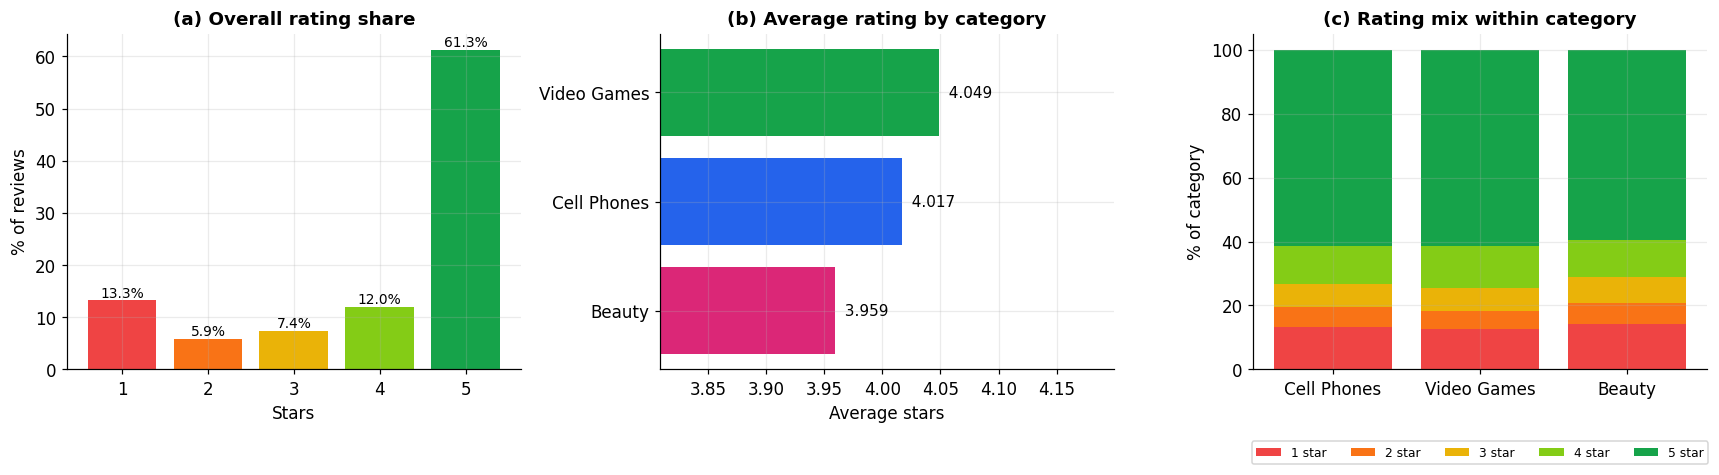

In [16]:
so = sat_overall.toPandas()
sbc = sat_by_cat.toPandas().sort_values("avg_rating")
pv = cat_mix.toPandas().set_index("Category")
pv.columns = [str(c) for c in pv.columns]
pv = pv.reindex([c for c in CATS if c in pv.index])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

ax[0].bar(so["rating"].astype(int).astype(str), so["pct"], color=STAR_COLORS)
ax[0].set_title("(a) Overall rating share"); ax[0].set_xlabel("Stars"); ax[0].set_ylabel("% of reviews")
for i, p in enumerate(so["pct"]):
    ax[0].text(i, p, f"{p}%", ha="center", va="bottom", fontsize=9)

ax[1].barh(sbc["Category"], sbc["avg_rating"], color=[ccol(c) for c in sbc["Category"]])
lo, hi = sbc["avg_rating"].min(), sbc["avg_rating"].max()
ax[1].set_xlim(max(0, lo - 0.15), hi + 0.15)
ax[1].set_title("(b) Average rating by category"); ax[1].set_xlabel("Average stars")
for i, v in enumerate(sbc["avg_rating"]):
    ax[1].text(v, i, f"  {v}", va="center", fontsize=10)

bottom = np.zeros(len(pv))
for star, col in zip(["1.0", "2.0", "3.0", "4.0", "5.0"], STAR_COLORS):
    if star not in pv.columns:
        continue
    vals = pv[star].astype(float).values
    ax[2].bar(pv.index, vals, bottom=bottom, label=f"{star[0]} star", color=col)
    bottom = bottom + vals
ax[2].set_title("(c) Rating mix within category"); ax[2].set_ylabel("% of category")
ax[2].legend(ncol=5, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.30))

plt.tight_layout()
savefig(fig, "fig02_customer_satisfaction", "Objective 1 - satisfaction overall and by category")
plt.show()

## 6. Objective 2 - Verified-Purchase Analysis

Verified and non-verified reviews are compared on rating, helpful votes and length. The
differences are reported descriptively. A gap here is not evidence of fraud, because a verified
badge can still sit on a manipulated review when a seller supplies a free unit, so the badge is
treated as something to measure rather than a settled trust signal.


In [17]:
verified_cmp = (df.groupBy("verified_purchase")
                .agg(F.count("*").alias("reviews"),
                     F.round(100 * F.count("*") / n_clean, 1).alias("share_pct"),
                     F.round(F.avg("rating"), 3).alias("avg_rating"),
                     F.round(F.avg("helpful_vote"), 3).alias("avg_helpful_vote"),
                     F.round(F.avg("review_length"), 1).alias("avg_review_length"),
                     F.round(100 * F.avg((F.col("rating") >= 4).cast("int")), 1).alias("pct_positive"))
                .orderBy(F.desc("verified_purchase")))
verified_cmp.show(truncate=False)

verified_by_cat = (df.groupBy("Category", "verified_purchase")
                   .agg(F.round(F.avg("rating"), 3).alias("avg_rating"),
                        F.count("*").alias("reviews"))
                   .orderBy("Category", F.desc("verified_purchase")))
print("Verified vs non-verified within each category")
verified_by_cat.show(truncate=False)

save_table(verified_cmp, "obj2_verified_comparison")
save_table(verified_by_cat, "obj2_verified_by_category");

+-----------------+-------+---------+----------+----------------+-----------------+------------+
|verified_purchase|reviews|share_pct|avg_rating|avg_helpful_vote|avg_review_length|pct_positive|
+-----------------+-------+---------+----------+----------------+-----------------+------------+
|true             |485468 |93.1     |4.031     |0.614           |174.6            |73.6        |
|false            |35805  |6.9      |3.886     |1.928           |524.9            |70.0        |
+-----------------+-------+---------+----------+----------------+-----------------+------------+

Verified vs non-verified within each category
+-----------+-----------------+----------+-------+
|Category   |verified_purchase|avg_rating|reviews|
+-----------+-----------------+----------+-------+
|Beauty     |true             |3.943     |12823  |
|Beauty     |false            |4.104     |1345   |
|Cell Phones|true             |4.02      |393593 |
|Cell Phones|false            |3.967     |21592  |
|Video Games|t

figure saved -> /kaggle/working/figures/fig03_verified_purchase.png


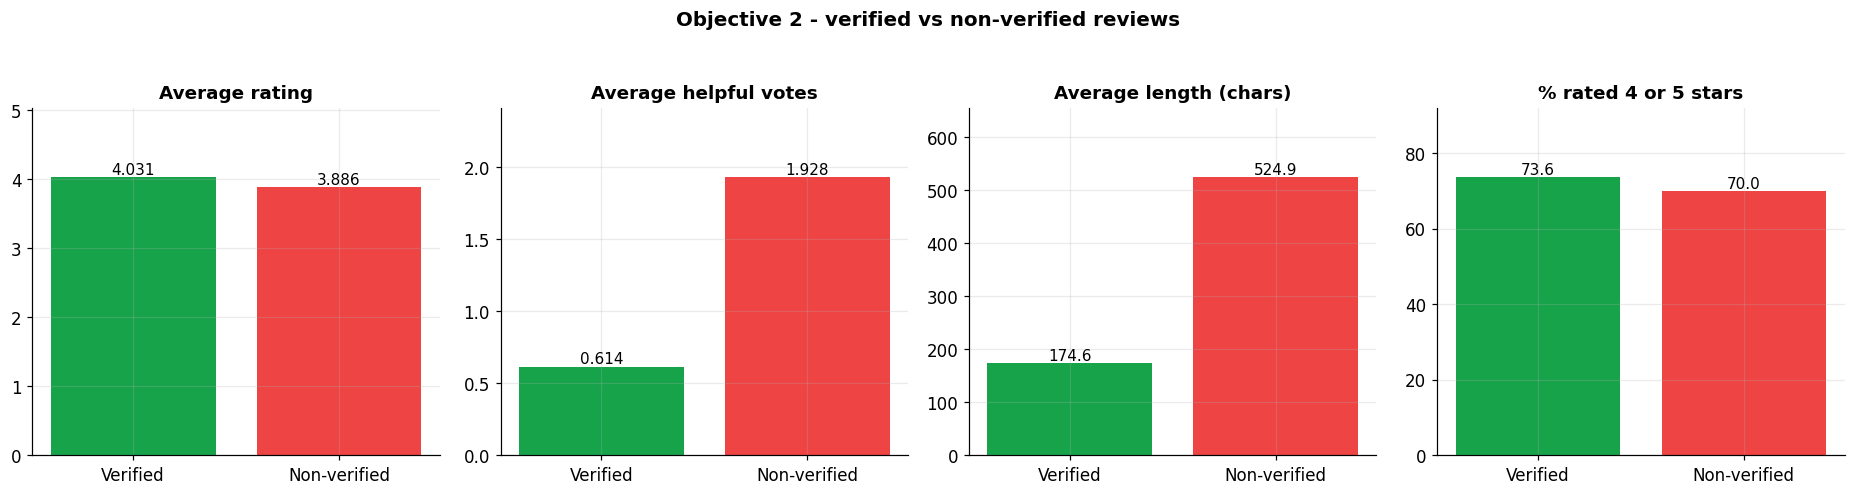

In [18]:
vc = verified_cmp.toPandas()
vc["group"] = vc["verified_purchase"].map({True: "Verified", False: "Non-verified"})
palette = {"Verified": "#16a34a", "Non-verified": "#ef4444"}

fig, ax = plt.subplots(1, 4, figsize=(17, 4.3))
panels = [("avg_rating", "Average rating"), ("avg_helpful_vote", "Average helpful votes"),
          ("avg_review_length", "Average length (chars)"), ("pct_positive", "% rated 4 or 5 stars")]
for a, (col, title) in zip(ax, panels):
    a.bar(vc["group"], vc[col], color=[palette[g] for g in vc["group"]])
    a.set_title(title)
    a.set_ylim(0, vc[col].max() * 1.25)
    for i, v in enumerate(vc[col]):
        a.text(i, v, f"{v}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Objective 2 - verified vs non-verified reviews", y=1.04, fontsize=13, fontweight="bold")
plt.tight_layout()
savefig(fig, "fig03_verified_purchase", "Objective 2 - verified vs non-verified behaviour")
plt.show()

## 7. Objective 3 - Helpful-Review Analysis

In [19]:
top_helpful = (df.select("helpful_vote", "rating", "Category", "review_length",
                         F.substring("title", 1, 45).alias("title"),
                         F.substring("text", 1, 60).alias("text_preview"))
               .orderBy(F.desc("helpful_vote")).limit(10))
print("Top 10 most-helpful reviews")
top_helpful.show(truncate=False)

help_by_rating = (df.groupBy("rating")
                  .agg(F.round(F.avg("helpful_vote"), 3).alias("avg_helpful"),
                       F.max("helpful_vote").alias("max_helpful"),
                       F.round(100 * F.avg((F.col("helpful_vote") >= 1).cast("int")), 1).alias("pct_with_vote"),
                       F.round(100 * F.avg("is_highly_helpful"), 2).alias("pct_highly_helpful"))
                  .orderBy("rating"))
overall_help = df.agg(F.round(F.avg("helpful_vote"), 3).alias("avg"),
                      F.round(100 * F.avg((F.col("helpful_vote") >= 1).cast("int")), 1).alias("pct_any")).first()
print(f"Overall: average helpful votes = {overall_help['avg']}, "
      f"reviews with at least one vote = {overall_help['pct_any']}%")
help_by_rating.show()

save_table(top_helpful, "obj3_top_helpful_reviews")
save_table(help_by_rating, "obj3_helpful_by_rating");

Top 10 most-helpful reviews


+------------+------+-----------+-------------+---------------------------------------------+------------------------------------------------------------+
|helpful_vote|rating|Category   |review_length|title                                        |text_preview                                                |
+------------+------+-----------+-------------+---------------------------------------------+------------------------------------------------------------+
|7663        |1.0   |Video Games|119          |Worse Launch In Game History                 |Between Nvidia, Sony and Microsoft,  They all suck at launch|
|2841        |1.0   |Video Games|72           |Not wireless                                 |When I cut off the cord to make it wireless, didn't work, do|
|1821        |5.0   |Video Games|3037         |Great value for the 50 dollar range headsets |FIrst off, this is a great value for the money, its hands-do|
|1481        |5.0   |Cell Phones|87           |The camera part is hard

table saved  -> obj3_top_helpful_reviews  (10 rows)
table saved  -> obj3_helpful_by_rating  (5 rows)


figure saved -> /kaggle/working/figures/fig04_helpful_reviews.png


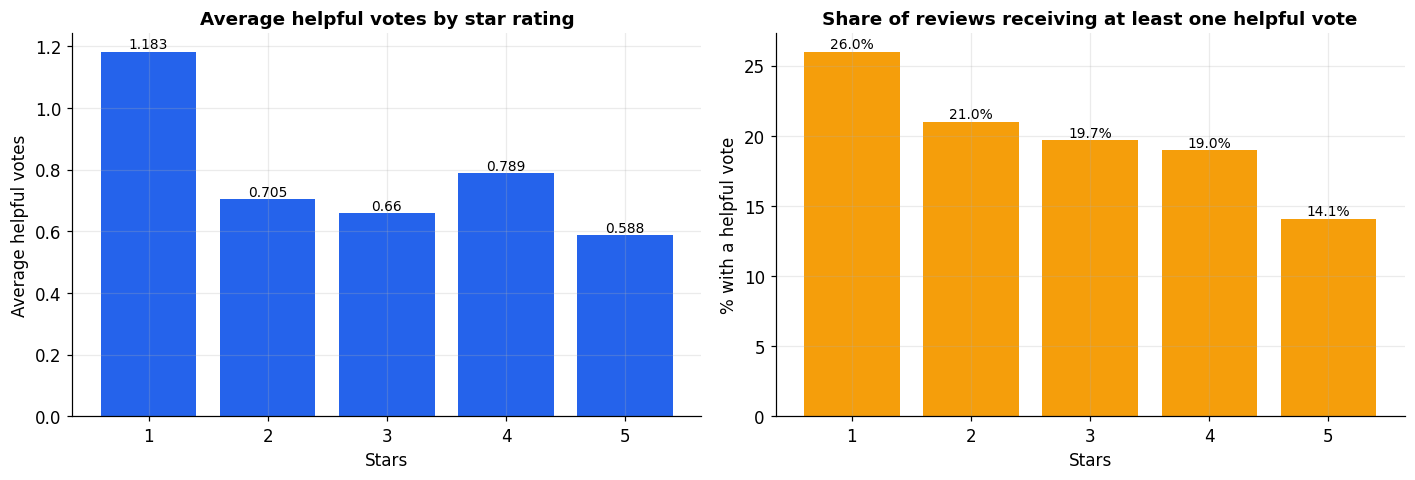

In [20]:
hbr = help_by_rating.toPandas()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(hbr["rating"].astype(int).astype(str), hbr["avg_helpful"], color=ACCENT)
ax[0].set_title("Average helpful votes by star rating")
ax[0].set_xlabel("Stars"); ax[0].set_ylabel("Average helpful votes")
for i, v in enumerate(hbr["avg_helpful"]):
    ax[0].text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)

ax[1].bar(hbr["rating"].astype(int).astype(str), hbr["pct_with_vote"], color="#f59e0b")
ax[1].set_title("Share of reviews receiving at least one helpful vote")
ax[1].set_xlabel("Stars"); ax[1].set_ylabel("% with a helpful vote")
for i, v in enumerate(hbr["pct_with_vote"]):
    ax[1].text(i, v, f"{v}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
savefig(fig, "fig04_helpful_reviews", "Objective 3 - helpfulness by star rating")
plt.show()

## 8. Objective 4 - Temporal Trend Analysis

In [21]:
yearly = (df.groupBy("review_year")
          .agg(F.count("*").alias("reviews"),
               F.round(F.avg("rating"), 3).alias("avg_rating"),
               F.round(F.avg("helpful_vote"), 3).alias("avg_helpful"),
               F.round(F.avg("review_length"), 1).alias("avg_length"))
          .orderBy("review_year"))
print("Yearly review volume, rating and engagement")
yearly.show(40, truncate=False)

n_surge = df.filter(F.col("review_year").between(2019, 2021)).count()
n_before = df.filter(F.col("review_year").between(2016, 2018)).count()
peak = yearly.orderBy(F.desc("reviews")).first()
print(f"Reviews 2019-2021: {n_surge:,} vs 2016-2018: {n_before:,} "
      f"(x{n_surge/max(n_before,1):.1f})")
print(f"Busiest year: {peak['review_year']} with {peak['reviews']:,} reviews")

save_table(yearly, "obj4_yearly_trend");

Yearly review volume, rating and engagement
+-----------+-------+----------+-----------+----------+
|review_year|reviews|avg_rating|avg_helpful|avg_length|
+-----------+-------+----------+-----------+----------+
|1999       |15     |4.467     |10.067     |568.5     |
|2000       |87     |4.31      |6.207      |884.3     |
|2001       |219    |4.091     |5.251      |985.4     |
|2002       |287    |4.056     |4.373      |900.3     |
|2003       |278    |4.126     |3.522      |1058.1    |
|2004       |319    |3.984     |5.038      |1194.1    |
|2005       |394    |3.832     |6.657      |1268.8    |
|2006       |382    |3.809     |9.534      |1237.7    |
|2007       |747    |3.921     |5.469      |830.3     |
|2008       |985    |3.789     |4.077      |788.7     |
|2009       |1350   |3.897     |3.05       |748.7     |
|2010       |2041   |3.85      |3.007      |745.1     |
|2011       |3571   |3.861     |2.513      |646.2     |
|2012       |6468   |3.912     |1.764      |487.9     |
|201

figure saved -> /kaggle/working/figures/fig05_temporal_trend.png


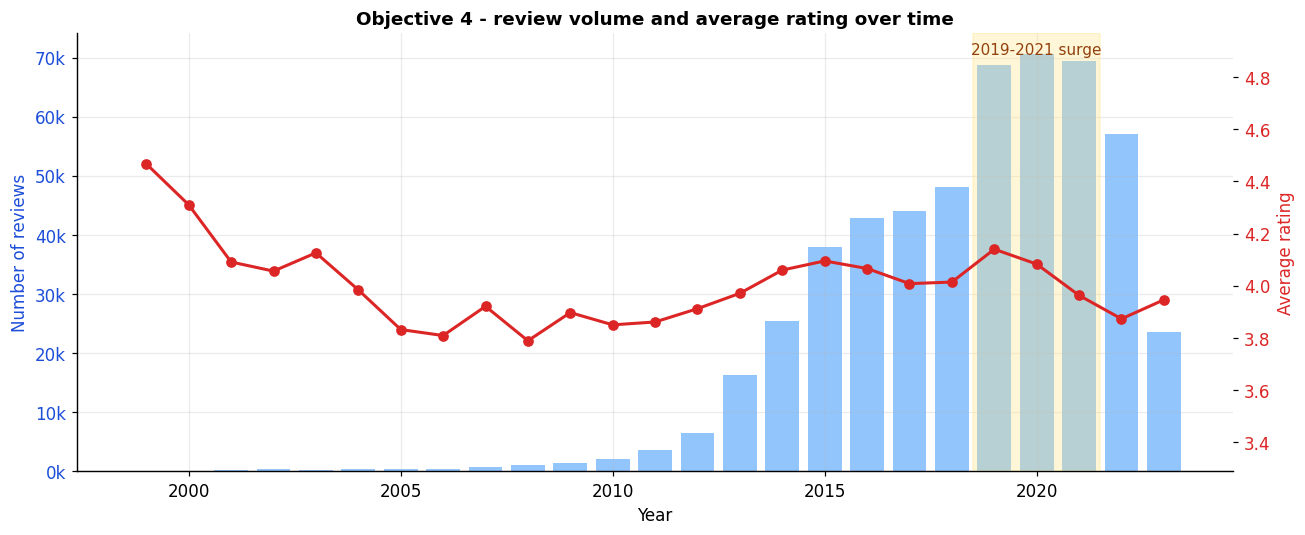

In [22]:
yr = yearly.toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(yr["review_year"], yr["reviews"], color="#93c5fd", label="Review volume")
ax1.set_xlabel("Year"); ax1.set_ylabel("Number of reviews", color="#1d4ed8")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax1.tick_params(axis="y", labelcolor="#1d4ed8")

ax2 = ax1.twinx()
ax2.plot(yr["review_year"], yr["avg_rating"], color="#dc2626", marker="o", lw=2, label="Average rating")
ax2.set_ylabel("Average rating", color="#dc2626")
ax2.set_ylim(max(1, yr["avg_rating"].min() - 0.5), min(5.05, yr["avg_rating"].max() + 0.5))
ax2.tick_params(axis="y", labelcolor="#dc2626"); ax2.grid(False)
ax2.axvspan(2018.5, 2021.5, color="#fde68a", alpha=0.35)
ax2.annotate("2019-2021 surge", xy=(2020, ax2.get_ylim()[1] - 0.08),
             ha="center", fontsize=10, color="#92400e")

plt.title("Objective 4 - review volume and average rating over time")
fig.tight_layout()
savefig(fig, "fig05_temporal_trend", "Objective 4 - volume and rating, 1999 to 2023")
plt.show()

figure saved -> /kaggle/working/figures/fig06_category_trend.png


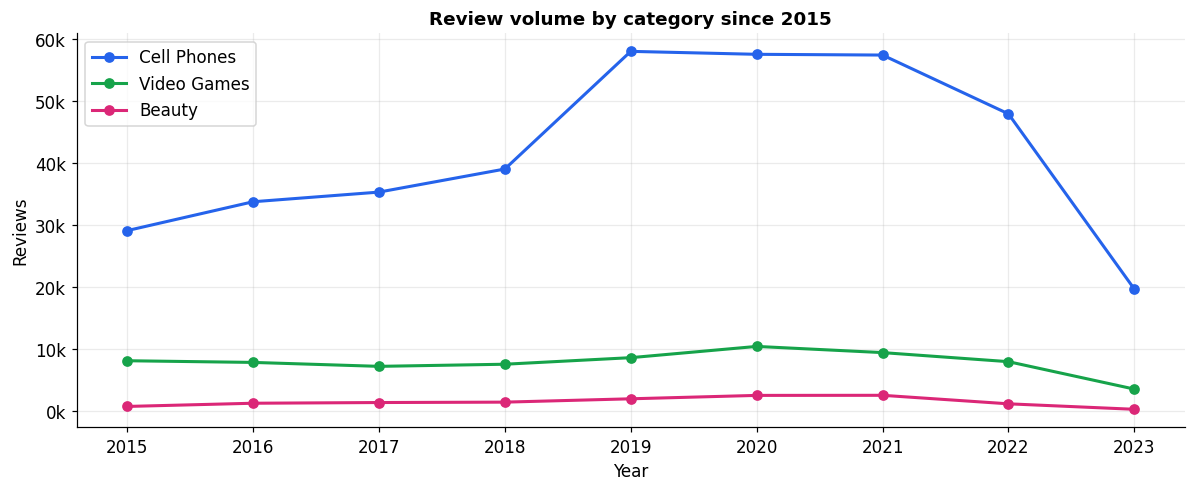

table saved  -> obj4_category_yearly  (27 rows)


In [23]:
cat_year = (df.filter(F.col("review_year") >= 2015)
            .groupBy("review_year", "Category").count().orderBy("review_year"))
cy = cat_year.toPandas()

fig, ax = plt.subplots(figsize=(11, 4.6))
for cat in CATS:
    sub = cy[cy["Category"] == cat]
    if len(sub):
        ax.plot(sub["review_year"], sub["count"], marker="o", label=cat, color=ccol(cat), lw=2)
ax.set_title("Review volume by category since 2015")
ax.set_xlabel("Year"); ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend()
plt.tight_layout()
savefig(fig, "fig06_category_trend", "Objective 4 - per-category volume since 2015")
plt.show()

save_table(cat_year, "obj4_category_yearly");

## 9. Checkpoint 1 Summary

The dataset loads under a declared schema, profiles cleanly, and survives preprocessing with the
row-count audit trail showing exactly what each step removed. Features are derived once into a
cached DataFrame that the remaining objectives read from.

Four objectives are answered here. Ratings are J-shaped rather than bell-shaped, which already
tells us that product ranking in Checkpoint 2 will need a minimum-review threshold. The verified
badge covers most of the corpus, so on its own it separates very little. Helpful votes reach only
a small minority of reviews. And review volume is concentrated in the recent years rather than
spread evenly across the 24-year span.

Checkpoint 2 continues from this same cached DataFrame with product analytics, customer activity,
text analytics, window functions and the PySpark versus Pandas benchmark.


In [24]:
print(f"Tables written to {TBL_DIR} ({len(RESULTS)} tables, CSV + Parquet)")
for name in sorted(RESULTS):
    print(f"  {name:<38} {len(RESULTS[name]):>6,} rows")

print(f"\nFigures written to {FIG_DIR} ({len(FIGURES)} figures, 300 dpi PNG)")
for name in sorted(FIGURES):
    print(f"  {name}.png")

print("\nCheckpoint 1 complete.")

Tables written to /kaggle/working/results (16 tables, CSV + Parquet)
  obj1_rating_distribution                    5 rows
  obj1_rating_mix_by_category                 3 rows
  obj1_satisfaction_by_category               3 rows
  obj2_verified_by_category                   6 rows
  obj2_verified_comparison                    2 rows
  obj3_helpful_by_rating                      5 rows
  obj3_top_helpful_reviews                   10 rows
  obj4_category_yearly                       27 rows
  obj4_yearly_trend                          25 rows
  tbl01_dataset_summary                       9 rows
  tbl02_category_distribution                 3 rows
  tbl03_rating_distribution                   5 rows
  tbl04_category_stats                        3 rows
  tbl05_length_by_rating                      5 rows
  tbl06_helpful_vote_profile                  7 rows
  tbl07_preprocessing_audit                   6 rows

Figures written to /kaggle/working/figures (6 figures, 300 dpi PNG)
  fig01_datase

In [25]:
for name in ["df", "raw"]:
    obj = globals().get(name)
    if obj is not None and hasattr(obj, "unpersist"):
        try:
            obj.unpersist()
        except Exception:
            pass

spark.stop()
print("Spark session stopped.")

Spark session stopped.
